# Visium HD Resolution Horizon and Tuft/Stem Niche

This notebook inspects the resolution-horizon workflow and tuft/stem niche analysis. Smoke mode uses synthetic spatial proportions; full mode uses downloaded Visium HD and Haber reference data.

In [1]:
from pathlib import Path
import os
import sys


def find_repo_root(start):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "repro").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise RuntimeError("Could not locate repository root; start Jupyter from the repository or notebooks directory.")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

from repro.paths import get_runtime_config

CONFIG = get_runtime_config(data_dir="data", results_dir="results")
DATA_DIR = CONFIG.data_dir
RESULTS_DIR = CONFIG.results_dir
RUN_MODE = CONFIG.run_mode

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def path_label(path, env_name):
    raw = os.environ.get(env_name)
    if raw and Path(raw).is_absolute():
        return f"${env_name}"
    try:
        return str(Path(path).resolve().relative_to(REPO_ROOT))
    except ValueError:
        return str(path)


config = pd.DataFrame([
    {"setting": "run_mode", "value": RUN_MODE},
    {"setting": "data_dir", "value": path_label(DATA_DIR, "FD_DATA_DIR")},
    {"setting": "results_dir", "value": path_label(RESULTS_DIR, "FD_RESULTS_DIR")},
])
display(config)


,setting,value
0,run_mode,smoke
1,data_dir,data
2,results_dir,results


## Build or Load Multiscale Results

Smoke mode creates a compact spatial grid with brush-cell and stem-cell hotspots. Full mode runs the same shared functions used by the CLI script.

In [2]:

from repro.paths import missing_inputs_message
from repro.visium_hd import (
    analyze_colocalization,
    compute_resolution_metrics,
    flatten_multiscale_proportions,
    run_multiscale_analysis,
)

if RUN_MODE == "full":
    visium_root = DATA_DIR / "Visium_HD_Mouse_Small_Intestine_binned_outputs"
    required = [
        visium_root / "square_016um" / "filtered_feature_bc_matrix.h5",
        visium_root / "square_016um" / "spatial" / "tissue_positions.parquet",
    ]
    if not any((DATA_DIR / name).exists() for name in ["haber_intestine_matched.h5ad", "haber_processed.h5ad"]):
        required.append(DATA_DIR / "haber_processed.h5ad")
    message = missing_inputs_message(required, "bash scripts/download_visium_hd_data.sh ./data")
    if message:
        raise FileNotFoundError(message)
    results, cell_types = run_multiscale_analysis(DATA_DIR, RESULTS_DIR, [16, 32, 64, 128])
    metrics_df = compute_resolution_metrics(results, cell_types)
    props_df = flatten_multiscale_proportions(results)
else:
    rng = np.random.default_rng(42)
    results = {}
    cell_types = ["brush cell", "epithelial fate stem cell", "enterocyte", "goblet cell"]
    for bin_size, side in [(16, 28), (32, 18), (64, 12), (128, 8)]:
        x, y = np.meshgrid(np.arange(side), np.arange(side))
        coords = np.column_stack([x.ravel(), y.ravel()]) * bin_size
        center = np.array([side * bin_size * 0.58, side * bin_size * 0.42])
        dist = np.linalg.norm(coords - center, axis=1)
        brush = np.exp(-(dist / (bin_size * 2.0)) ** 2) * (0.34 * 16 / bin_size)
        stem = np.exp(-(dist / (bin_size * 2.8)) ** 2) * (0.45 * 16 / bin_size)
        enterocyte = 0.50 + rng.normal(0, 0.015, len(coords))
        goblet = 0.08 + rng.normal(0, 0.008, len(coords))
        props = pd.DataFrame({
            "brush cell": np.clip(brush, 0, 0.5),
            "epithelial fate stem cell": np.clip(stem, 0, 0.6),
            "enterocyte": np.clip(enterocyte, 0, 1),
            "goblet cell": np.clip(goblet, 0, 1),
        })
        row_sums = props.sum(axis=1)
        props = props.div(row_sums, axis=0)
        results[bin_size] = {"proportions": props, "coords": coords, "n_spots": len(coords), "time": 0.0}
    metrics_df = compute_resolution_metrics(results, cell_types)
    props_df = flatten_multiscale_proportions(results)

display(metrics_df.head(8))


,bin_size,cell_type,cv,max_prop,pct_detectable,pct_high,morans_i,mean_prop
0,16,brush cell,4.854674,0.245481,6.632653,2.168367,0.084317,0.005417
1,16,epithelial fate stem cell,3.342045,0.329518,13.520408,5.994898,0.091010,0.016398
2,16,enterocyte,0.083341,0.905424,100.000000,100.000000,0.087266,0.843669
3,16,goblet cell,0.119236,0.174103,100.000000,96.683673,0.038471,0.134516
4,32,brush cell,3.178801,0.163502,13.580247,3.703704,0.081261,0.008226
5,32,epithelial fate stem cell,2.137360,0.226906,27.160494,9.876543,0.088827,0.023349
6,32,enterocyte,0.078740,0.896944,100.000000,100.000000,0.084731,0.835383
7,32,goblet cell,0.116094,0.170264,100.000000,96.604938,0.035406,0.133043


## Tuft/Stem Enrichment Check

In [3]:

finest = props_df[props_df["bin_size"] == props_df["bin_size"].min()].copy()
coloc_df = analyze_colocalization(finest)
visibility_df = pd.DataFrame({
    "cell_type": ["brush cell", "epithelial fate stem cell", "enterocyte", "goblet cell"],
    "hvg_blindness": [24.0, 8.5, -2.0, 3.0],
})
display(coloc_df.head())


,cell_type,enrichment,mean_in_hotspot,mean_elsewhere
0,epithelial fate stem cell,28.720838,0.294151,0.010242
2,goblet cell,0.562146,0.076342,0.135805
1,enterocyte,0.545700,0.464971,0.852063


## Compact Preview

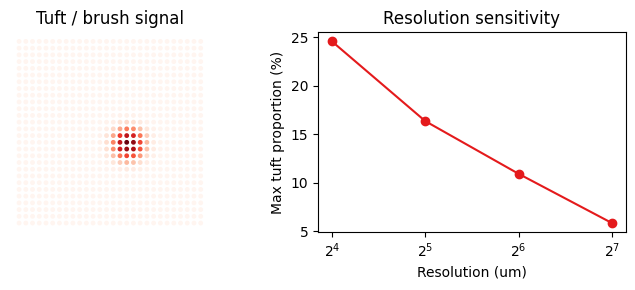

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].scatter(finest["coord_x"], finest["coord_y"], c=finest["brush cell"], s=6, cmap="Reds")
axes[0].set_title("Tuft / brush signal")
axes[0].set_aspect("equal")
axes[0].axis("off")
subset = metrics_df[metrics_df["cell_type"] == "brush cell"].sort_values("bin_size")
axes[1].plot(subset["bin_size"], subset["max_prop"] * 100, "o-", color="#e41a1c")
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("Resolution (um)")
axes[1].set_ylabel("Max tuft proportion (%)")
axes[1].set_title("Resolution sensitivity")
plt.tight_layout()
plt.show()
